# Thesis figures (musclemap-bench)

Run with working directory = `musclemap-bench`.

Prerequisites:
- `python precompute/run_kinesis.py --config config.yaml --test-split-only`
- `python scripts/build_test_paired_curves.py --config config.yaml`
- `python scripts/run_benchmark.py --config config.yaml --export-timings`
- `python scripts/profile_paired_inference.py`

All accuracy plots use **test-paired** metrics only (windows with Kinesis artifacts, 42 leg muscles).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display, Markdown

from src.curve_data import interpolate_curve
from src.loaders import load_config, _resolve_path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config.yaml").exists() and (REPO_ROOT.parent / "config.yaml").exists():
    REPO_ROOT = REPO_ROOT.parent

cfg = load_config(REPO_ROOT / "config.yaml")
RESULTS_DIR = _resolve_path(cfg["paths"]["results_dir"])
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

results_path = RESULTS_DIR / "results.json"
results = json.loads(results_path.read_text(encoding="utf-8")) if results_path.exists() else {}

paired_csv = _resolve_path(cfg["paths"]["curves_dir"]) / "test_paired_metrics.csv"
if not paired_csv.exists():
    raise FileNotFoundError("Run scripts/build_test_paired_curves.py first")
df = pd.read_csv(paired_csv).sort_values("epoch").reset_index(drop=True)

paired = results.get("layer1_paired", {})
kin_mae = paired.get("kinesis", {}).get("mae") or cfg["baselines"]["kinesis_test_paired"]["mae"]
kin_rmse = paired.get("kinesis", {}).get("rmse") or cfg["baselines"]["kinesis_test_paired"]["rmse"]
n_paired = int(df["n_paired_windows"].iloc[0])

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Repo: {REPO_ROOT}; paired windows: {n_paired}")

Repo: /Users/maksimpecin/Library/CloudStorage/OneDrive-Личная/Thesis/code/musclemap-bench; paired windows: 319


## Figure A — Test-paired MAE/RMSE vs optimizer step

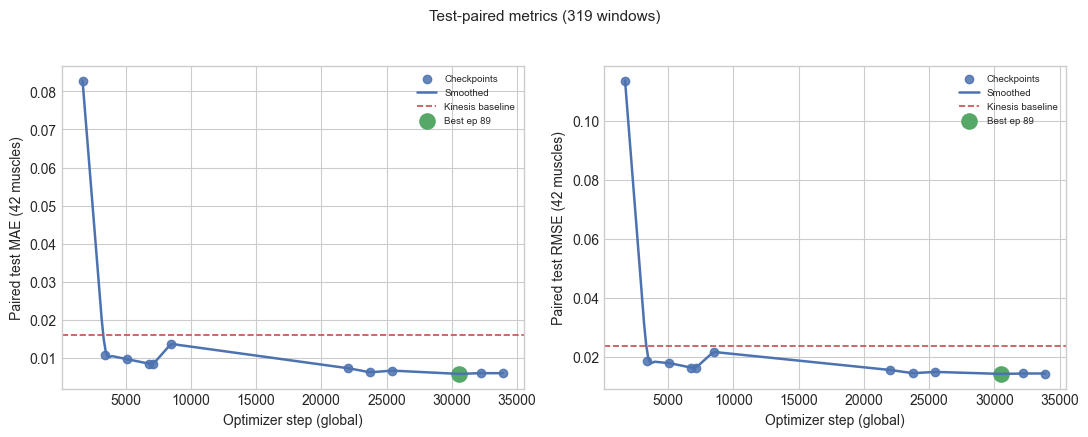

Wrote /Users/maksimpecin/Library/CloudStorage/OneDrive-Личная/Thesis/code/musclemap-bench/results/plots/training_mae_rmse_vs_step.png; best ep 89 MAE=0.0057


In [2]:
from scipy.signal import savgol_filter

step_min, step_max = int(df["global_step"].min()), int(df["global_step"].max())
step_grid = np.linspace(step_min, step_max, 200)
n_ckpt = len(df)
window = min(7, n_ckpt if n_ckpt % 2 else max(n_ckpt - 1, 3))
if window % 2 == 0:
    window -= 1
window = max(window, 3)
poly = min(2, window - 1)
mae_smooth = savgol_filter(interpolate_curve(df, step_grid, value_col="mae"), window_length=window, polyorder=poly)
rmse_smooth = savgol_filter(interpolate_curve(df, step_grid, value_col="rmse"), window_length=window, polyorder=poly)
best_ep = df.loc[df["mae"].idxmin()]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
for ax, metric, smooth, kin_val, ylab in zip(
    axes,
    ("mae", "rmse"),
    (mae_smooth, rmse_smooth),
    (float(kin_mae), float(kin_rmse)),
    ("Paired test MAE (42 muscles)", "Paired test RMSE (42 muscles)"),
):
    ax.scatter(df["global_step"], df[metric], color="#4C72B0", s=36, alpha=0.85, label="Checkpoints")
    ax.plot(step_grid, smooth, color="#4C72B0", linewidth=1.8, label="Smoothed")
    ax.axhline(kin_val, color="#C44E52", linestyle="--", linewidth=1.2, label="Kinesis baseline")
    ax.set_ylabel(ylab)
    ax.set_xlabel("Optimizer step (global)")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(f"Test-paired metrics ({n_paired} windows)", y=1.03, fontsize=11)
fig.tight_layout()
out_a = PLOTS_DIR / "training_mae_rmse_vs_step.png"
fig.savefig(out_a, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {out_a}; best ep {int(best_ep['epoch'])} MAE={best_ep['mae']:.4f}")

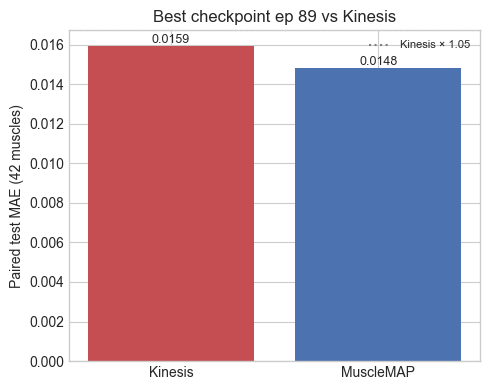

**Paired:** Kinesis 0.0159, MuscleMAP 0.0148 (-6.9%).

In [3]:
mm_mae = paired.get("musclemap", {}).get("mae", best_ep["mae"])
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Kinesis", "MuscleMAP"], [float(kin_mae), float(mm_mae)], color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Paired test MAE (42 muscles)")
ax.set_title(f"Best checkpoint ep {int(best_ep['epoch'])} vs Kinesis")
ax.axhline(float(kin_mae) * 1.05, color="gray", linestyle=":", label="Kinesis × 1.05")
ax.legend(fontsize=8)
for i, v in enumerate([kin_mae, mm_mae]):
    ax.text(i, v, f"{float(v):.4f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
out_test = PLOTS_DIR / "test_paired_mae_vs_kinesis.png"
fig.savefig(out_test, dpi=150, bbox_inches="tight")
plt.show()
display(Markdown(f"**Paired:** Kinesis {kin_mae:.4f}, MuscleMAP {float(mm_mae):.4f} ({(float(mm_mae)-kin_mae)/kin_mae*100:+.1f}%)."))

### Checkpoint table (test-paired)

,stem,epoch,global_step,mae,rmse,n_paired_windows,mae_vs_kinesis_pct
0,epoch_0004,4,1695,0.0828,0.1136,319,+420.4%
1,epoch_0009,9,3390,0.0108,0.0186,319,-32.0%
2,epoch_0014,14,5085,0.0096,0.0179,319,-39.6%
3,epoch_0019,19,6780,0.0084,0.0163,319,-47.2%
4,epoch_0020,20,7119,0.0084,0.0163,319,-47.2%
5,epoch_0024,24,8475,0.0136,0.0217,319,-14.4%
6,epoch_0064,64,22035,0.0072,0.0155,319,-54.5%
7,epoch_0069,69,23730,0.0062,0.0144,319,-61.3%
8,epoch_0074,74,25425,0.0066,0.0149,319,-58.6%
9,epoch_0089,89,30510,0.0057,0.0142,319,-64.0%


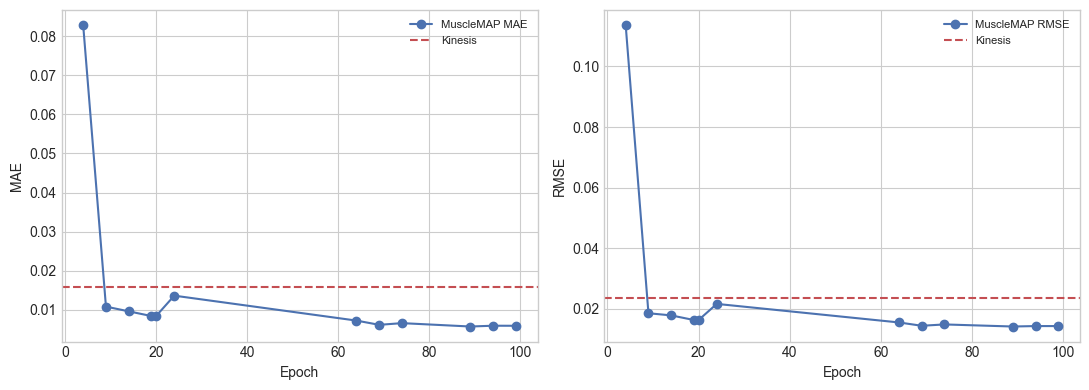

Wrote /Users/maksimpecin/Library/CloudStorage/OneDrive-Личная/Thesis/code/musclemap-bench/results/plots/test_paired_metrics_by_checkpoint.png


In [4]:
summary = df[["stem", "epoch", "global_step", "mae", "rmse", "n_paired_windows"]].copy()
summary["mae_vs_kinesis_pct"] = (summary["mae"] - kin_mae) / kin_mae * 100
display(summary.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "mae_vs_kinesis_pct": "{:+.1f}%"}))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, col, ylab in ((axes[0], "mae", "MAE"), (axes[1], "rmse", "RMSE")):
    ax.plot(summary["epoch"], summary[col], marker="o", color="#4C72B0", label=f"MuscleMAP {ylab}")
    kin_col = kin_mae if col == "mae" else kin_rmse
    ax.axhline(float(kin_col), color="#C44E52", linestyle="--", label="Kinesis")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylab)
    ax.legend(fontsize=8)
fig.tight_layout()
out_ckpt = PLOTS_DIR / "test_paired_metrics_by_checkpoint.png"
fig.savefig(out_ckpt, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {out_ckpt}")

## Figure B — Inference time (paired windows only)

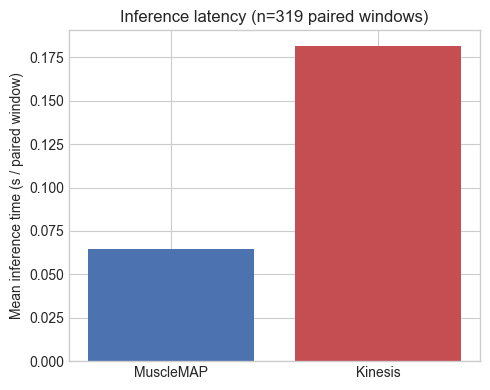

Wrote /Users/maksimpecin/Library/CloudStorage/OneDrive-Личная/Thesis/code/musclemap-bench/results/plots/inference_time_mean.png


In [5]:
profile_path = RESULTS_DIR / "inference_profile.json"
profile = json.loads(profile_path.read_text(encoding="utf-8")) if profile_path.exists() else {}
paired_inf = profile.get("paired_inference", {})
mm_t = paired_inf.get("musclemap", results.get("resources", {}).get("musclemap", {}).get("inference", {}))
kin_t = paired_inf.get("kinesis", results.get("resources", {}).get("kinesis", {}).get("inference", {}))
labels, means = ["MuscleMAP", "Kinesis"], [mm_t.get("mean_s"), kin_t.get("mean_s")]
if all(m is not None for m in means):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(labels, [float(m) for m in means], color=["#4C72B0", "#C44E52"])
    ax.set_ylabel("Mean inference time (s / paired window)")
    ax.set_title(f"Inference latency (n={paired_inf.get('n_paired_windows', n_paired)} paired windows)")
    fig.tight_layout()
    out_b = PLOTS_DIR / "inference_time_mean.png"
    fig.savefig(out_b, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_b}")
else:
    print("Run scripts/profile_paired_inference.py and scripts/run_benchmark.py --export-timings")

## Figure C — Training compute vs paired test MAE

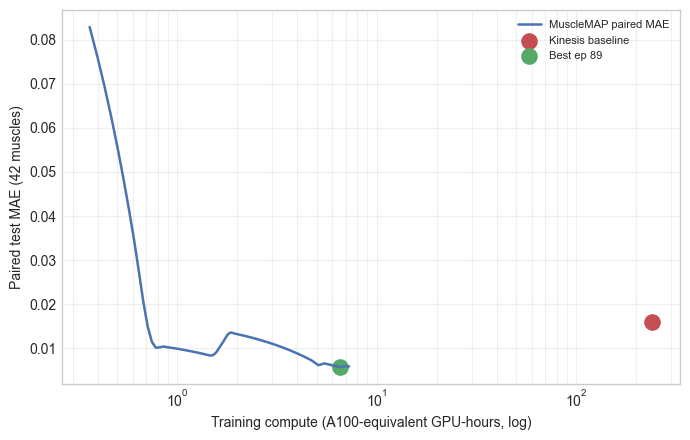

Wrote /Users/maksimpecin/Library/CloudStorage/OneDrive-Личная/Thesis/code/musclemap-bench/results/plots/training_compute_vs_mae.png


In [6]:
def _norm_gpu_hours(gpus, hours, gpu_type, *, ref_gpu, perf):
    if hours is None:
        return None
    scale = float(perf.get(gpu_type, 1.0)) / float(perf.get(ref_gpu, 1.0))
    return float(gpus) * float(hours) * scale

r_cfg = cfg["resources"]
ref_gpu = r_cfg.get("compute_reference_gpu", "A100")
perf = r_cfg.get("gpu_relative_performance", {"V100-16GB": 0.52, "A100": 1.0, "A100-80GB": 1.0})
mm_hours = r_cfg.get("musclemap_training_hours") or 14
mm_norm_h = _norm_gpu_hours(r_cfg["musclemap_training_gpus"], mm_hours, r_cfg.get("musclemap_training_gpu_type", "V100-16GB"), ref_gpu=ref_gpu, perf=perf)
kin_norm_h = _norm_gpu_hours(r_cfg.get("kinesis_training_gpus", 1), r_cfg.get("kinesis_training_hours"), r_cfg.get("kinesis_training_gpu_type", "A100"), ref_gpu=ref_gpu, perf=perf)
step_max = float(np.max(step_grid))
mm_compute_h = mm_norm_h * (np.asarray(step_grid, dtype=np.float64) / step_max)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mm_compute_h, mae_smooth, color="#4C72B0", linewidth=1.8, label="MuscleMAP paired MAE")
ax.scatter([kin_norm_h], [float(kin_mae)], s=120, color="#C44E52", label="Kinesis baseline")
ax.set_xscale("log")
ax.set_xlabel(f"Training compute ({ref_gpu}-equivalent GPU-hours, log)")
ax.set_ylabel("Paired test MAE (42 muscles)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
out_c = PLOTS_DIR / "training_compute_vs_mae.png"
fig.savefig(out_c, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {out_c}")